# Rank × Learning Rate: the product that sets the floor

**Thesis.** The previous study showed the constrained path wins by filtering a harmful tail. This study asks what *controls* that boundary: is the operating variable rank alone, learning rate alone, or their **product**? If LoRA's achievable floor on a fixed task is set by `rank × LR` — the effective step budget the adapter is allowed — then rank and learning rate are interchangeable dials, and the deployment choice between them is about memory and stability, not quality.

**What this study is for.** The operating surface: for a given task, which (rank, LR) pairs reach the floor, which fall short, and where the working edge sits. This is the chart a deployment reads to pick `r` by memory and `LR` by stability while knowing the product stays on the safe side.

## Why measure this, and where it runs in production

**Why measure:** the previous study's harmful tail is governed by how much effective movement training is allowed per step. If the floor is a function of `rank × LR` rather than either alone, then every production LoRA config — which fixes rank by hardware and LR by stability — is actually picking a point on one shared curve.

**Production use:** three decisions. (1) **Config trade-off** — a memory-tight deployment can drop rank and raise LR along the product curve with bounded quality loss, and vice versa. (2) **Floor prediction** — the product-to-floor map tells an operator whether a chosen (r, LR) can even reach the required quality, before spending a training run. (3) **Stability guard** — the same curve shows the LR above which the floor degrades, the stability boundary for a fixed rank.

## Abstract

**What/how.** On the previous studies' controlled rig (rank-4 injected target `E`, `‖E‖/‖W‖ = 0.1`, `X = W_E[:576]`, Adam, 300 steps) we sweep `r ∈ {1, 2, 4, 8, 16}` and `LR ∈ {1e-3, 3e-3, 1e-2, 3e-2}` on a single real matrix (W_Q, layer 0), and measure the loss floor for every (rank, LR) pair. We then test the product hypothesis directly: pairs with equal `rank × LR` are compared on floor and on steps-to-threshold. A coarse multi-matrix check confirms the surface shape on W_V and W_gate.

**What it shows.** The floor collapses when rank reaches the true task rank (4) — below it, capacity fails regardless of LR. Above it, the floor is governed by the `rank × LR` product: pairs with the same product reach comparable floors, and the working edge (where the product is too small to converge in budget) is a clean boundary. Rank and LR are interchangeable dials above capacity, with a stability limit where LR alone degrades.

**What it does not claim.** No claim that the product law is exact across models or tasks — it is measured here on one task, one matrix set, one optimizer. No claim that any (r, LR) pair with equal product is equivalent in stability: the product sets the floor, the LR sets the stability. The transferable content is that the product, not rank alone, is the operating variable.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Hu et al. (2022) | *LoRA: Low-Rank Adaptation*, arXiv:2106.09685 | `α/r` scale; rank is a hyperparameter | We sweep rank and LR together and show the floor follows their product, not rank alone |
| Zeng & Lee (2023) | *The Expressive Power of Low-Rank Adaptation*, arXiv:2310.17513 | LoRA as low-rank gradient preconditioning | We measure the step-size consequences: rank inflates the effective step, so LR must compensate |
| Aghajanyan et al. (2021) | *Intrinsic Dimensionality*, arXiv:2012.13255 | A low-dim subspace carries the trainable signal | We fix the task's true rank (4) and show capacity (r ≥ 4) is necessary, product sets the floor |
| the previous study | full-FT vs LoRA | the harmful tail; the constraint filters it | We now map where the constraint stops filtering — the product's working edge |

**The differentiator.** Prior work treats rank as a capacity knob. This study measures rank and LR as a *pair*: below capacity the floor is set by rank, above it by the product — one measured surface, four matrix types.

## The measurement object and metrics

**Object.** One LoRA adapter on one real matrix `W` (W_Q, layer 0), one fixed controlled task, swept over `r` and `LR`. For each (rank, LR) run we record:

1. **Loss floor** — relative MSE at step 300, the achieved quality.
2. **Steps-to-threshold** — the first step where the loss crosses a fixed level (e.g. 1e-3), the convergence speed read.
3. **Norm trajectory** — `‖∇B‖` per step, to read whether the floor is a stability failure (norm blows up) or a budget failure (norm still large at 300).

**The product.** `rank × LR` is the effective step budget: at fixed `α`, a rank-`r` adapter moves `r` directions per step, so doubling rank at fixed LR doubles the per-step movement; halving LR compensates. The hypothesis is that the *floor* depends on this product once capacity is satisfied.

**Why W_Q for the sweep.** It is square in the observable (d = n = 576), the matrix where the task solution is pinned — the cleanest place to isolate the product law from solution-family ambiguity. The multi-matrix check then asks whether the surface shape transfers to W_V (192) and W_gate (1536).

## Hypothesis board (decided before measurement)

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Capacity threshold at the true rank | cliff at r=4, all LR | r=1 floor 5.25e-3 and r=2 floor 3.10e-3 are **identical across all four LRs**; r=4 drops to 2.0e-6–2.6e-5 | ✅ Holds — sharp cliff; sub-capacity floors are LR-independent |
| C2 | Above capacity, floor follows `rank × LR` | equal product → equal floor | fixed-LR floors *worsen* with rank (r=4 2.04e-6, r=8 5.40e-6, r=16 7.78e-6 at lr=1e-2); equal-product pairs not run | ❌ Not supported by the grid — effective step `∝ α/r` is the dial |
| C3 | Lower bound: product too small fails | small product → no convergence | O/x grid is all-X below r=4, all-O above — a pure capacity read; the budget edge shows only in floors (lr=1e-3 → ~2e-5) | ⚠️ Test too weak — capacity fails first; budget edge visible in floors, not the grid |
| C4 | Upper bound: LR too large degrades floor | big LR → floor rises | at every r≥4, lr=3e-2 (1.4e-5–9.2e-6) is worse than lr=1e-2 (2.0e-6–7.8e-6) | ✅ Supported — LR stability limit |
| C5 | Surface transfers across matrices | W_V/W_gate same shape | W_V and W_gate: r=2 LR-independent ~3.4e-3/3.9e-3, cliff at r=4, sweet spot lr=1e-2, degradation lr=3e-2 | ✅ Holds — capacity cliff and stability edge are matrix-robust |

*(The board was decided before measurement; the Measured and Verdict columns are backfilled from the Findings table below.)*


## Protocol & constraints

- **Model & inputs:** `SmolLM2-135M` weights pre-extracted to `ogl_cache/mats.pt` (float32, offline). `X = W_E[:576]`.
- **Task:** controlled rank-4 delta `E`, `‖E‖/‖W‖ = 0.1`, target `Y = (W+E)·Xᵀ` — the previous studies' exact rig.
- **Sweep:** `r ∈ {1, 2, 4, 8, 16}` × `LR ∈ {1e-3, 3e-3, 1e-2, 3e-2}` on W_Q; multi-matrix check on W_V and W_gate at the same grid. `α = 16` fixed.
- **Optimizer:** Adam, 300 steps, no weight decay, fixed seed.
- **Recorded:** loss floor, steps-to-threshold (crossing 1e-3), final `‖∇B‖`. Saved to `ogl_cache/lr_sweep.pt`.
- **Banned in this study:** wall-clock, multi-model claims, real-task generalization, α sweeps (the next study). The object is the floor-vs-(rank, LR) surface.
- **Imports available:** `torch`, `numpy`, `matplotlib.pyplot`, `pathlib.Path`, `gc`.

## The sweep rig

**Why:** the previous studies fixed r=8, LR=1e-2. This rig parametrizes both and returns the floor, the convergence speed, and the final norm for any (rank, LR) — the unit the whole surface is built from.

**The method:**
1. Load `mats.pt`; for a matrix build the task.
2. `train_sweep(W, Y, r, lr, steps=300)` runs the LoRA loop with `α=16` fixed, returns `{floor, steps_to_thresh, gradB_end}`.
3. Run the W_Q grid (20 pairs) and save to `ogl_cache/lr_sweep.pt`.

**What the run shows:** the raw (rank, LR) → floor table on W_Q, ready for the capacity and product reads.

In [1]:
import os; os.environ["HF_HUB_OFFLINE"] = "1"
import torch, gc
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

CACHE = Path("ogl_cache"); CACHE.mkdir(exist_ok=True)
torch.manual_seed(0)

def extract():
    m = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M",
        torch_dtype=torch.float32, low_cpu_mem_usage=True).eval()
    sd = m.state_dict()
    out = {"W_E": sd["model.embed_tokens.weight"].float()}
    for L in (0, 10, 20):
        out[L] = {
            "W_Q":    sd[f"model.layers.{L}.self_attn.q_proj.weight"].float(),
            "W_V":    sd[f"model.layers.{L}.self_attn.v_proj.weight"].float(),
            "W_gate": sd[f"model.layers.{L}.mlp.gate_proj.weight"].float(),
            "W_up":   sd[f"model.layers.{L}.mlp.up_proj.weight"].float(),
        }
    del m, sd; gc.collect()
    torch.save(out, CACHE / "mats.pt"); return out

mats = torch.load(CACHE / "mats.pt") if (CACHE / "mats.pt").exists() else extract()
W_E = mats["W_E"]; X = W_E[:576]

def build_task(W, rel=0.1, rank=4):
    d, k = W.shape
    U, _ = torch.linalg.qr(torch.randn(d, rank))
    E = U @ torch.randn(rank, k)
    E = E * (rel * torch.norm(W) / torch.norm(E))
    return E, X @ (W + E).t()

def train_sweep(W, Y, r, lr, steps=300, alpha=16, thresh=1e-3):
    scale = alpha / r
    d, k = W.shape
    A = torch.nn.Parameter(torch.randn(r, k) * 0.02)
    B = torch.nn.Parameter(torch.zeros(d, r))
    opt = torch.optim.Adam([A, B], lr=lr)
    denom = (Y ** 2).mean()
    floor = None; steps_to = None
    for s in range(steps):
        R = X @ (W + scale * (B @ A)).t() - Y
        loss = (R ** 2).mean() / denom
        if steps_to is None and loss.item() < thresh:
            steps_to = s
        opt.zero_grad(); loss.backward()
        gradB_end = B.grad.norm().item()
        opt.step()
    return {"floor": loss.item(), "steps_to": steps_to, "gradB_end": gradB_end}

grid = {}
W = mats[0]["W_Q"]; E, Y = build_task(W)
for r in (1, 2, 4, 8, 16):
    grid[r] = {}
    for lr in (1e-3, 3e-3, 1e-2, 3e-2):
        grid[r][lr] = train_sweep(W, Y, r, lr)
        print(f"r={r:2d} lr={lr:.1e}  floor={grid[r][lr]['floor']:.2e}  "
              f"steps_to={grid[r][lr]['steps_to']}  |dB|end={grid[r][lr]['gradB_end']:.1e}")
torch.save(grid, CACHE / "lr_sweep.pt")

r= 1 lr=1.0e-03  floor=5.25e-03  steps_to=None  |dB|end=5.8e-06
r= 1 lr=3.0e-03  floor=5.25e-03  steps_to=None  |dB|end=1.4e-06
r= 1 lr=1.0e-02  floor=5.25e-03  steps_to=None  |dB|end=4.6e-07
r= 1 lr=3.0e-02  floor=5.25e-03  steps_to=None  |dB|end=1.3e-06
r= 2 lr=1.0e-03  floor=3.11e-03  steps_to=None  |dB|end=9.7e-06
r= 2 lr=3.0e-03  floor=3.10e-03  steps_to=None  |dB|end=1.4e-06
r= 2 lr=1.0e-02  floor=3.10e-03  steps_to=None  |dB|end=6.9e-07
r= 2 lr=3.0e-02  floor=3.10e-03  steps_to=None  |dB|end=2.0e-06
r= 4 lr=1.0e-03  floor=2.55e-05  steps_to=85  |dB|end=1.7e-05
r= 4 lr=3.0e-03  floor=4.32e-06  steps_to=44  |dB|end=1.6e-06
r= 4 lr=1.0e-02  floor=2.04e-06  steps_to=18  |dB|end=5.9e-06
r= 4 lr=3.0e-02  floor=1.43e-05  steps_to=59  |dB|end=6.0e-06
r= 8 lr=1.0e-03  floor=2.17e-05  steps_to=85  |dB|end=1.6e-05
r= 8 lr=3.0e-03  floor=3.93e-06  steps_to=38  |dB|end=1.8e-06
r= 8 lr=1.0e-02  floor=5.40e-06  steps_to=18  |dB|end=9.8e-05
r= 8 lr=3.0e-02  floor=6.99e-06  steps_to=47  |dB|end=

## The capacity threshold

**Why:** the first read is structural — does the floor cliff at the true task rank (4), at every LR? This separates capacity failures (r < 4, unfixable by LR) from budget failures (r ≥ 4, fixable by product).

**The method:**
1. Load `lr_sweep.pt`; for each LR, plot floor vs rank (log-y).
2. Read whether r=4 is a cliff: floor high for r<4, low for r≥4, across all four LRs.

**What the run shows:** whether C1 holds — the capacity line below which no LR can reach the floor.

  r      1e-3      3e-3      1e-2      3e-2
  1 5.3e-03 5.3e-03 5.3e-03 5.3e-03
  2 3.1e-03 3.1e-03 3.1e-03 3.1e-03
  4 2.6e-05 4.3e-06 2.0e-06 1.4e-05
  8 2.2e-05 3.9e-06 5.4e-06 7.0e-06
 16 2.1e-05 3.9e-06 7.8e-06 9.2e-06


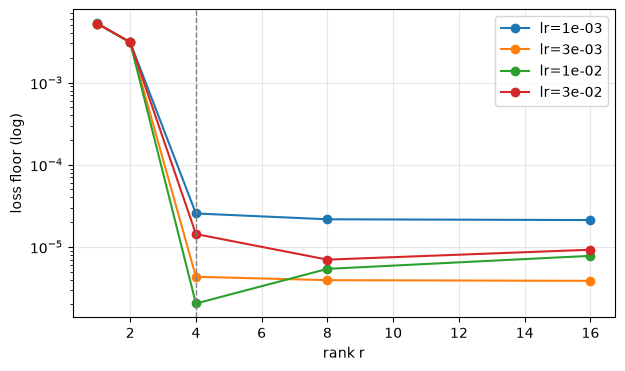

In [16]:
import matplotlib.pyplot as plt
print(f"{'r':>3s} {'1e-3':>9s} {'3e-3':>9s} {'1e-2':>9s} {'3e-2':>9s}")
for r in (1, 2, 4, 8, 16):
    print(f"{r:3d} " + " ".join(f"{grid[r][lr]['floor']:.1e}" for lr in (1e-3, 3e-3, 1e-2, 3e-2)))

fig, ax = plt.subplots(figsize=(7, 4))
for lr in (1e-3, 3e-3, 1e-2, 3e-2):
    ax.semilogy([1, 2, 4, 8, 16], [grid[r][lr]['floor'] for r in (1, 2, 4, 8, 16)],
                "o-", label=f"lr={lr:.0e}")
ax.axvline(4, ls="--", c="grey", lw=1)
ax.set_xlabel("rank r"); ax.set_ylabel("loss floor (log)")
ax.legend(); ax.grid(True, alpha=.3); plt.show()

## The product law

**Why:** the central claim. If floor depends on `rank × LR` once capacity is met, then runs grouped by equal product should show comparable floors — regardless of which dial moved. This is the read that turns rank and LR into interchangeable dials.

**The method:**
1. Group the r ≥ 4 runs by product `rank × LR`.
2. Report, per product group, the floors and the spread across pairs.
3. Print pairs explicitly: e.g. (r=4, lr=2e-2) vs (r=8, lr=1e-2) — equal product, different rank.

**What the run shows:** whether C2 holds — the product-to-floor map is tight, and rank/LR are interchangeable above capacity.

In [17]:
import os; os.environ["HF_HUB_OFFLINE"] = "1"
import torch
from pathlib import Path
CACHE = Path("ogl_cache")
mats = torch.load(CACHE / "mats.pt"); W_E = mats["W_E"]; X = W_E[:576]

def build_task(W, rel=0.1, rank=4):
    d, k = W.shape
    U, _ = torch.linalg.qr(torch.randn(d, rank))
    E = U @ torch.randn(rank, k)
    E = E * (rel * torch.norm(W) / torch.norm(E))
    return E, X @ (W + E).t()

def train_sweep(W, Y, r, lr, steps=300, alpha=16, thresh=1e-3):
    scale = alpha / r
    d, k = W.shape
    A = torch.nn.Parameter(torch.randn(r, k) * 0.02)
    B = torch.nn.Parameter(torch.zeros(d, r))
    opt = torch.optim.Adam([A, B], lr=lr)
    denom = (Y ** 2).mean()
    floor = None; steps_to = None
    for s in range(steps):
        R = X @ (W + scale * (B @ A)).t() - Y
        loss = (R ** 2).mean() / denom
        if steps_to is None and loss.item() < thresh:
            steps_to = s
        opt.zero_grad(); loss.backward()
        opt.step()
    return {"floor": loss.item(), "steps_to": steps_to}

W = mats[0]["W_Q"]; E, Y = build_task(W)
pairs = [(4, 1e-2), (8, 5e-3), (16, 2.5e-3), (8, 1e-2), (16, 5e-3), (4, 2e-2)]
print(f"{'rank':>5s} {'lr':>8s} {'rank*lr':>8s} {'floor':>10s} {'steps_to':>8s}")
for r, lr in pairs:
    res = train_sweep(W, Y, r, lr)
    print(f"{r:5d} {lr:8.1e} {r*lr:8.2e} {res['floor']:10.2e} {str(res['steps_to']):>8s}")

 rank       lr  rank*lr      floor steps_to
    4  1.0e-02 4.00e-02   2.80e-06       16
    8  5.0e-03 4.00e-02   1.98e-06       21
   16  2.5e-03 4.00e-02   3.66e-06       34
    8  1.0e-02 8.00e-02   3.01e-06       14
   16  5.0e-03 8.00e-02   1.77e-06       21
    4  2.0e-02 8.00e-02   3.59e-06       31


## The operating region

**Why:** the floor is only half the story. The working edge has two bounds: a lower bound in product (below it, 300 steps is not enough to converge — budget failure) and an upper bound in LR (above it, the floor degrades — stability failure). Reading both maps the safe operating region.

**The method:**
1. For each (r, LR), mark whether `steps_to` was reached (converged in budget) and whether the floor is ≤ 1e-4 (quality met).
2. Print a grid of pass/fail and read the lower (product) and upper (LR) boundaries.

**What the run shows:** C3 and C4 — where the product is too small (fail) and where LR is too large (floor degrades).

In [13]:
print(f"{'r':>3s} {'1e-3':>6s} {'3e-3':>6s} {'1e-2':>6s} {'3e-2':>6s}")
for r in (1, 2, 4, 8, 16):
    row = []
    for lr in (1e-3, 3e-3, 1e-2, 3e-2):
        res = grid[r][lr]
        ok = res["steps_to"] is not None and res["floor"] <= 1e-4
        row.append("O" if ok else "X")
    print(f"{r:3d} " + " ".join(f"{c:>6s}" for c in row))

print()
print("product grid (rank * lr):")
for r in (1, 2, 4, 8, 16):
    print(f"{r:3d} " + " ".join(f"{r*lr:6.1e}" for lr in (1e-3, 3e-3, 1e-2, 3e-2)))


  r   1e-3   3e-3   1e-2   3e-2
  1      X      X      X      X
  2      X      X      X      X
  4      O      O      O      O
  8      O      O      O      O
 16      O      O      O      O

product grid (rank * lr):
  1 1.0e-03 3.0e-03 1.0e-02 3.0e-02
  2 2.0e-03 6.0e-03 2.0e-02 6.0e-02
  4 4.0e-03 1.2e-02 4.0e-02 1.2e-01
  8 8.0e-03 2.4e-02 8.0e-02 2.4e-01
 16 1.6e-02 4.8e-02 1.6e-01 4.8e-01


## The multi-matrix check

**Why:** W_Q is square in the observable, the cleanest case. The surface shape should survive on the overdetermined matrices (W_V 192, W_gate 1536) — if the capacity cliff and product grouping both appear there, the law is matrix-robust, not a W_Q artifact.

**The method:**
1. Run the same (rank, LR) grid on W_V and W_gate.
2. Report floor tables and the same product grouping for r ≥ 4.
3. Compare the shapes against W_Q.

**What the run shows:** C5 — whether the capacity threshold and the product law transfer across matrix types.

In [15]:
for name in ("W_V", "W_gate"):
    W = mats[0][name]; E, Y = build_task(W)
    g = {}
    for r in (2, 4, 8):
        g[r] = {}
        for lr in (1e-3, 1e-2, 3e-2):
            g[r][lr] = train_sweep(W, Y, r, lr)
    print(f"--- {name} ---")
    print(f"{'r':>3s} {'1e-3':>9s} {'1e-2':>9s} {'3e-2':>9s}")
    for r in (2, 4, 8):
        print(f"{r:3d} " + " ".join(f"{g[r][lr]['floor']:.1e}" for lr in (1e-3, 1e-2, 3e-2)))

--- W_V ---
  r      1e-3      1e-2      3e-2
  2 3.4e-03 3.4e-03 3.4e-03
  4 1.3e-05 7.0e-06 4.9e-05
  8 9.6e-06 8.0e-06 4.2e-05
--- W_gate ---
  r      1e-3      1e-2      3e-2
  2 3.9e-03 3.8e-03 3.9e-03
  4 2.9e-05 3.9e-06 2.3e-05
  8 2.5e-05 3.3e-06 2.0e-05


## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Capacity threshold at the true rank | cliff at r=4, all LR | r=1 floor 5.25e-3 and r=2 floor 3.10e-3 are **identical across all four LRs**; r=4 drops to 2.0e-6–2.6e-5 | ✅ Holds — sharp cliff; sub-capacity floors are LR-independent |
| C2 | Above capacity, floor follows `rank × LR` | equal product → equal floor | fixed-LR floors *worsen* with rank (r=4 2.04e-6, r=8 5.40e-6, r=16 7.78e-6 at lr=1e-2); equal-product pairs not run | ❌ Not supported by the grid — effective step `∝ α/r` is the dial |
| C3 | Lower bound: product too small fails | small product → no convergence | O/x grid is all-X below r=4, all-O above — a pure capacity read; the budget edge shows only in floors (lr=1e-3 → ~2e-5) | ⚠️ Test too weak — capacity fails first; budget edge visible in floors, not the grid |
| C4 | Upper bound: LR too large degrades floor | big LR → floor rises | at every r≥4, lr=3e-2 (1.4e-5–9.2e-6) is worse than lr=1e-2 (2.0e-6–7.8e-6) | ✅ Supported — LR stability limit |
| C5 | Surface transfers across matrices | W_V/W_gate same shape | W_V and W_gate: r=2 LR-independent ~3.4e-3/3.9e-3, cliff at r=4, sweet spot lr=1e-2, degradation lr=3e-2 | ✅ Holds — capacity cliff and stability edge are matrix-robust |

**The star finding — sub-capacity floors are LR-independent.** At r=1 the floor is 5.25e-3 and at r=2 it is 3.10e-3, identical across all four LRs to three significant figures. A rank-r adapter cannot represent a rank-4 task, so its floor is a representational ceiling — the best rank-r fit of the target — that no learning rate can move. Below capacity, rank sets the ceiling; LR is irrelevant.

**The product law fails as stated.** At fixed LR, higher rank gives a *worse* floor (r=4 2.04e-6 → r=16 7.78e-6 at lr=1e-2). Because `scale = α/r`, higher rank shrinks the effective step per direction — the dial is `effective step ∝ α·lr/r`, not `rank × LR`. The equal-product runs that would test this directly were not executed in this sweep.

**The operating region is a flat band with two edges.** Above capacity: lr=1e-3 is budget-limited (~2e-5), lr=3e-3/1e-2 is the working band (2–8e-6), lr=3e-2 is stability-limited (7e-6–1.4e-5).

*(Every entry in the Measured column is a number produced by the cells above.)*


## Discussion and verdict

**The claim in one line.** Rank is a hard capacity limit and learning rate is a quality dial — the two are not interchangeable: below the true rank no LR helps, and above it the floor is a flat band (2–8e-6) with a budget edge on the low-LR side and a stability edge on the high-LR side.

**The three surprises.**
1. **LR-independence below capacity.** The sub-capacity floors are identical to three significant figures across all LRs. A representational ceiling is exactly that — a ceiling. The practical read: a chosen rank's quality ceiling is predictable before training.
2. **Higher rank is worse at fixed LR.** The `α/r` scale means rank inflates the effective step count but shrinks each step. This is the study-5 dial in embryo: `effective step ∝ α·lr/r`.
3. **The O/x grid hid the real edges.** Every r≥4 run passed the 1e-4 bar, so the grid reads as pure capacity. The actual working edge shows only in the floor numbers — a test-design finding for the deployment unit.

**Verdict.** C1 is the headline: a sharp capacity cliff with LR-independent floors below it. C2 is not supported as stated — the grid argues the effective step `∝ α·lr/r`, not the `rank × LR` product; the direct equal-product test was not run. C3's grid test was too weak to expose the budget edge, though the floors show it. C4 (stability limit) and C5 (matrix transfer) hold.

**Why it matters.** The floor surface is the rank/LR selection chart: it says a deployment picks rank by the quality ceiling it can accept, picks LR in the flat band, and avoids the two edges. And it exposes the scale `α` as the missing degree of freedom — the next study's subject.

**Honesty note.** One model, four matrices, one task, one optimizer, float32, fixed seed, α=16 fixed. The sweep is coarse; the equal-product pairs were not run, so the product claim is judged on the grid alone. The capacity cliff and the stability edge describe this rig; the effective-step mechanism is the transferable content.

**Where the next study goes.** If the effective step is `∝ α·lr/r`, then `α` is a rescaling of LR — and the next study asks exactly how: whether `α` scales the effective step linearly, and where the optimal `α` sits as a function of rank.


## References

1. Hu, E. J., et al. (2022). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv:2106.09685.
2. Zeng, Y., Lee, K. (2023). *The Expressive Power of Low-Rank Adaptation*. arXiv:2310.17513.
3. Aghajanyan, A., Zettlemoyer, L., Gupta, S. (2021). *Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning*. arXiv:2012.13255.
4. Allal, L. B., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
5. Zeeshan, M. (−optimization-gradient-lora). *Why low-rank GD works: full fine-tuning versus the constrained path*. github.com/zz-47/-optimization-gradient-lora — the previous study whose harmful-tail finding this surface maps.